In [1]:
# ===============================
# 📦 IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import IsolationForest

In [3]:
# ===============================
# 📂 LOAD DATASET
# ===============================
file_path = r"C:\Users\Anna Bonna B. Ojel\Documents\Midterm exam\203 CASE STUDY A\Aquifer_Auser.csv"
df = pd.read_csv(file_path)


In [4]:
# ===============================
# 🧹 CLEAN DATA (FIX WARNING)
# ===============================
df = df.ffill()


In [5]:
df

,Date,Rainfall_Gallicano,Rainfall_Pontetetto,Rainfall_Monte_Serra,Rainfall_Orentano,Rainfall_Borgo_a_Mozzano,Rainfall_Piaggione,Rainfall_Calavorno,Rainfall_Croce_Arcana,Rainfall_Tereglio_Coreglia_Antelminelli,...,Temperature_Monte_Serra,Temperature_Ponte_a_Moriano,Temperature_Lucca_Orto_Botanico,Volume_POL,Volume_CC1,Volume_CC2,Volume_CSA,Volume_CSAL,Hydrometry_Monte_S_Quirico,Hydrometry_Piaggione
0,05/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,06/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,10.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,07/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.20,0.0,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,08/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.40,0.0,13.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,09/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.40,0.0,12.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8149,26/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.75,0.0,23.75,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.20,-1.03
8150,27/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.35,0.0,24.30,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.21,-1.03
8151,28/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.75,0.0,24.55,-6829.936207,-7455.505,-8724.261667,-5809.63,-3000.1,0.23,-1.03
8152,29/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.90,0.0,23.60,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.23,-1.02


In [6]:


# Automatically pick first groundwater column
target_col = None
for col in df.columns:
    if "Depth_to_Groundwater" in col:
        target_col = col
        break

# If not found, use first numeric column
if target_col is None:
    target_col = df.select_dtypes(include=np.number).columns[0]

print(f"\nUsing column: {target_col}")

data = df[[target_col]]




Using column: Depth_to_Groundwater_LT2


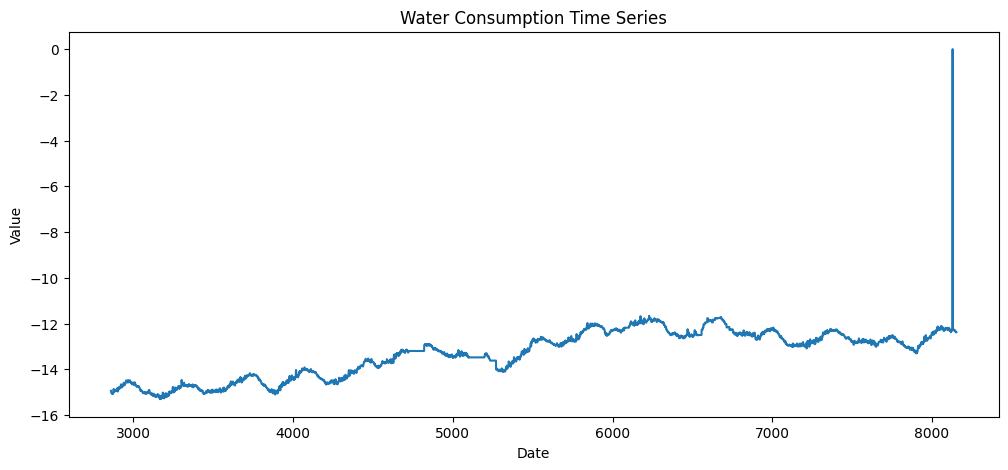

In [7]:
# ===============================
# 📊 VISUALIZATION
# ===============================
plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("Water Consumption Time Series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()


In [10]:
# 🔀 TRAIN-TEST SPLIT
# ===============================
train_size = int(len(data)*0.8)
train, test = data[:train_size], data[train_size:]

In [11]:
# ===============================
# 🤖 ARIMA MODEL
# ===============================
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()


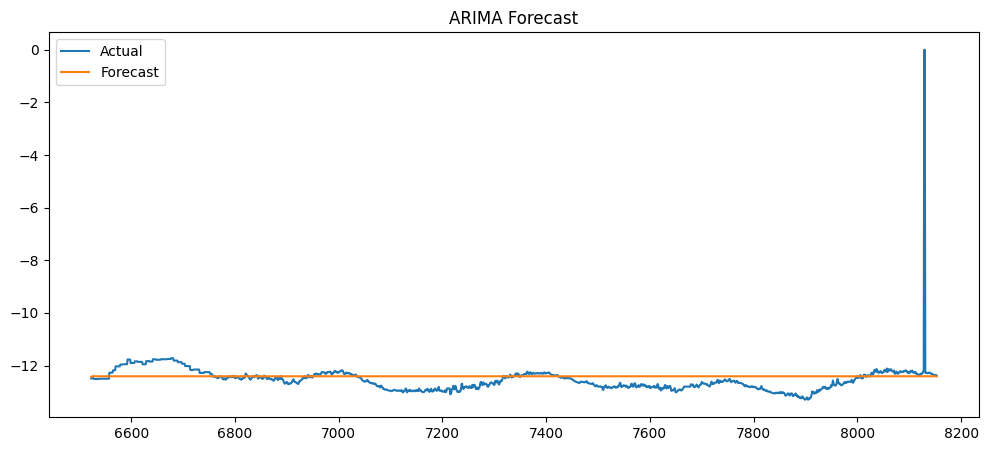

In [12]:

# 🔮 FORECAST
# ===============================
forecast = model_fit.forecast(steps=len(test))

# ===============================
# 📈 PLOT FORECAST
# ===============================
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()


Total anomalies detected: 0


C:\Users\Anna Bonna B. Ojel\AppData\Local\Temp\ipykernel_9688\314925934.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['anomaly'] = iso.fit_predict(data)


Text(0, 0.5, 'Value')

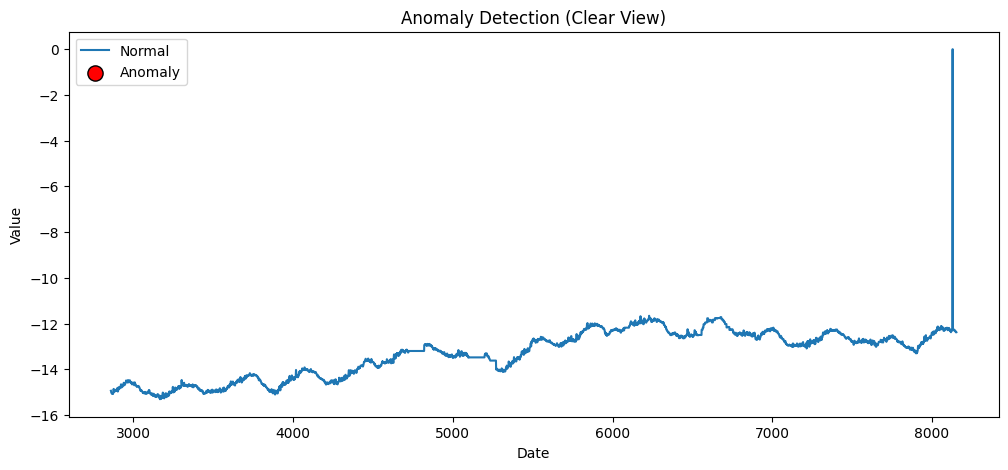

In [15]:
# ===============================
# 🚨 ANOMALY DETECTION
# ===============================
iso = IsolationForest(contamination=0.01)
data['anomaly'] = iso.fit_predict(data)

plt.figure(figsize=(12,5))
plt.plot(data.index, data[target_col], label='Normal')

anomalies = data[data['anomaly'] == -1]
# 🔴 Highlight anomalies clearly
plt.scatter(
    anomalies.index,
    anomalies[target_col],
    color='red',
    s=120,          # bigger points
    edgecolors='black',  # outline para klaro
    label="Anomaly",
    zorder=10
)

# 🔥 OPTIONAL: print anomaly count
print("Total anomalies detected:", len(anomalies))

plt.legend()
plt.title("Anomaly Detection (Clear View)")
plt.xlabel("Date")
plt.ylabel("Value")


C:\Users\Anna Bonna B. Ojel\AppData\Local\Temp\ipykernel_9688\1502347615.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['rolling_mean'] = data[target_col].rolling(window=30).mean()


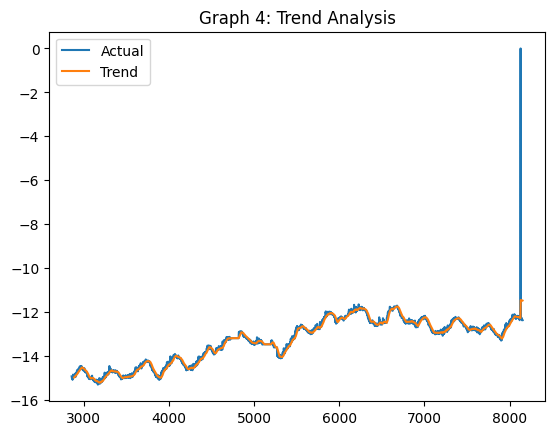

In [14]:
# ===============================
# 📉 TREND (ROLLING MEAN)
# ===============================
data['rolling_mean'] = data[target_col].rolling(window=30).mean()

# ===============================
# 📉 GRAPH 4: TREND ANALYSIS
# ===============================
plt.figure()
plt.plot(data[target_col], label="Actual")
plt.plot(data['rolling_mean'], label="Trend")
plt.legend()
plt.title("Graph 4: Trend Analysis")
plt.show()